# Phase 2.3: Uji Statistik Inferensial

**Tujuan:**  
Menguji apakah terdapat perbedaan signifikan pada metrik konektivitas EEG di antara
tiga kelas emosi (*negative, neutral, positive*) menggunakan uji statistik formal.

**Alur analisis:**
1. Uji Normalitas (Shapiro-Wilk)
2. Uji Homogenitas Varians (Levene's Test)
3. Keputusan Uji → ANOVA atau Kruskal-Wallis
4. Uji Utama (ANOVA / Kruskal-Wallis)
5. Uji Post-Hoc (Tukey / Dunn)
6. Effect Size (Cohen's f² atau Epsilon²)
7. Linear Mixed-Effects Model (LMM)
8. Significance Summary Heatmap

---

In [11]:
# ============================================================
# SEL INI: IMPORT LIBRARY & KONFIGURASI GLOBAL
# ------------------------------------------------------------
# Sel ini memuat semua library yang dibutuhkan (pandas, scipy,
# statsmodels, matplotlib, seaborn), mendefinisikan path folder
# input (Phase 1 CSV) dan output (CSV hasil uji & gambar),
# memuat semua 7 dataset (GC + 6 band PDC), serta melakukan
# strip prefiks kolom agar nama metrik menjadi generik
# (contoh: 'gc_mean_out_degree' -> 'mean_out_degree').
# PENTING: CLASS_COL = 'class_label' (teks) dipakai di semua
# operasi grouping & filter, BUKAN 'class' (angka 0/1/2).
# ============================================================

# ==============================================================================
# SECTION 0: IMPORT & KONFIGURASI
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from statsmodels.formula.api import mixedlm
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.facecolor'] = 'white'

# === PATH ===
PHASE1_DIR = Path(r'D:\Skripsi\new_data\phase_1_data_structuring\csv')
OUTPUT_DIR = Path(r'D:\Skripsi\new_data\phase_2_statistics\2.3_inferential_statistics\output')
FIG_DIR    = Path(r'D:\Skripsi\new_data\phase_2_statistics\2.3_inferential_statistics\figures')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# === KONVENSI KOLOM ===
# PENTING: class_label = teks emosi ('negative'/'neutral'/'positive')
#          class       = kode numerik (0/1/2) — JANGAN dipakai untuk grouping statistik
CLASS_COL = 'class_label'
EMOTIONS  = ['negative', 'neutral', 'positive']

MEAN_COLS = ['mean_out_degree', 'mean_in_degree', 'mean_total_degree',
             'mean_out_strength', 'mean_in_strength', 'mean_total_strength']
SHORT = {
    'mean_out_degree' : 'Out Deg',
    'mean_in_degree'  : 'In Deg',
    'mean_total_degree'  : 'Total Deg',
    'mean_out_strength'  : 'Out Str',
    'mean_in_strength'   : 'In Str',
    'mean_total_strength': 'Total Str',
}

DATASETS = {
    'GC'          : PHASE1_DIR / 'cleaned_graph_metrics_gc.csv',
    'PDC Delta'   : PHASE1_DIR / 'cleaned_graph_metrics_pdc_delta.csv',
    'PDC Theta'   : PHASE1_DIR / 'cleaned_graph_metrics_pdc_theta.csv',
    'PDC Alpha'   : PHASE1_DIR / 'cleaned_graph_metrics_pdc_alpha.csv',
    'PDC Beta'    : PHASE1_DIR / 'cleaned_graph_metrics_pdc_beta.csv',
    'PDC Gamma'   : PHASE1_DIR / 'cleaned_graph_metrics_pdc_gamma.csv',
    'PDC Broadband': PHASE1_DIR / 'cleaned_graph_metrics_pdc_broadband.csv',
}

# === LOAD & STRIP PREFIX ===
data = {}
for name, csv_path in DATASETS.items():
    if not csv_path.exists():
        print(f'  [SKIP] {name}: {csv_path}')
        continue
    df = pd.read_csv(csv_path)
    prefix = 'gc' if name == 'GC' else f"pdc_{name.lower().split()[-1]}"
    df = df.rename(columns={
        col: col.replace(f'{prefix}_', '', 1)
        for col in df.columns if col.startswith(f'{prefix}_')
    })
    data[name] = df
    print(f'  Loaded {name}: {df.shape} | {CLASS_COL}: {sorted(df[CLASS_COL].unique())}')

print(f'\nOutput : {OUTPUT_DIR}')
print(f'Figures: {FIG_DIR}')


  Loaded GC: (675, 4047) | class_label: ['negative', 'neutral', 'positive']
  Loaded PDC Delta: (675, 4047) | class_label: ['negative', 'neutral', 'positive']
  Loaded PDC Theta: (675, 4047) | class_label: ['negative', 'neutral', 'positive']
  Loaded PDC Alpha: (675, 4047) | class_label: ['negative', 'neutral', 'positive']
  Loaded PDC Beta: (675, 4047) | class_label: ['negative', 'neutral', 'positive']
  Loaded PDC Gamma: (675, 4047) | class_label: ['negative', 'neutral', 'positive']
  Loaded PDC Broadband: (675, 4047) | class_label: ['negative', 'neutral', 'positive']

Output : D:\Skripsi\new_data\phase_2_statistics\2.3_inferential_statistics\output
Figures: D:\Skripsi\new_data\phase_2_statistics\2.3_inferential_statistics\figures


---
## 1. Uji Normalitas (Shapiro-Wilk Test)

$H_0$: Data berdistribusi normal.  
Jika $p < 0.05$ → $H_0$ ditolak (data **TIDAK** normal → gunakan Kruskal-Wallis).

In [12]:
# ============================================================
# SEL INI: UJI NORMALITAS — SHAPIRO-WILK TEST
# ------------------------------------------------------------
# Menguji normalitas distribusi per kelas emosi per metrik.
# FIX: Metrik dengan zero variance (std=0, semua nilai sama)
#      di-skip secara otomatis dengan keterangan 'Zero Variance'
#      karena Shapiro-Wilk tidak bisa dijalankan pada data konstan.
# Output: shapiro_{method}.csv
# ============================================================
def shapiro_wilk_test(df):
    results = []
    for emotion in EMOTIONS:
        subset = df[df[CLASS_COL] == emotion]
        for col in MEAN_COLS:
            vals = subset[col].dropna()
            # FIX: skip jika semua nilai identik (std=0)
            if len(vals) < 3 or vals.std() < 1e-10:
                results.append({
                    'emotion': emotion, 'metric': SHORT[col],
                    'statistic': np.nan, 'p_value': np.nan,
                    'normal': False, 'note': 'Zero Variance - Skipped',
                })
                continue
            stat, p = stats.shapiro(vals)
            results.append({
                'emotion': emotion, 'metric': SHORT[col],
                'statistic': round(float(stat), 4),
                'p_value'  : round(float(p), 6),
                'normal'   : bool(p >= 0.05),
                'note'     : '',
            })
    return pd.DataFrame(results)

all_normality = {}
for name, df in data.items():
    norm = shapiro_wilk_test(df)
    all_normality[name] = norm
    print(f'\n{"="*70}')
    print(f'  {name} - Shapiro-Wilk Test')
    print(f'{"="*70}')
    skipped = norm[norm['note'] == 'Zero Variance - Skipped']
    if not skipped.empty:
        print(f'  [SKIP] Zero variance metrics: {skipped["metric"].unique().tolist()}')
    valid = norm[norm['note'] != 'Zero Variance - Skipped']
    if not valid.empty:
        pivot = valid.pivot_table(index='metric', columns='emotion', values='p_value')[EMOTIONS]
        print(pivot.round(4).to_string())
    n_norm = norm['normal'].sum()
    print(f'\n  Normal: {n_norm}/{len(norm)} kelompok (p >= 0.05)')
    norm.to_csv(OUTPUT_DIR / f'shapiro_{name.lower().replace(" ","_")}.csv', index=False)



  GC - Shapiro-Wilk Test
emotion    negative  neutral  positive
metric                                
In Deg          0.0      0.0       0.0
In Str          0.0      0.0       0.0
Out Deg         0.0      0.0       0.0
Out Str         0.0      0.0       0.0
Total Deg       0.0      0.0       0.0
Total Str       0.0      0.0       0.0

  Normal: 0/18 kelompok (p >= 0.05)

  PDC Delta - Shapiro-Wilk Test
emotion    negative  neutral  positive
metric                                
In Deg       0.0068   0.0042    0.0001
In Str       0.0255   0.0172    0.0038
Out Deg      0.0068   0.0042    0.0001
Out Str      0.0255   0.0172    0.0038
Total Deg    0.0068   0.0042    0.0001
Total Str    0.0255   0.0172    0.0038

  Normal: 0/18 kelompok (p >= 0.05)

  PDC Theta - Shapiro-Wilk Test
emotion    negative  neutral  positive
metric                                
In Deg       0.0273   0.0080    0.0001
In Str       0.0123   0.0008    0.0031
Out Deg      0.0273   0.0080    0.0001
Out Str      0.

---
## 2. Uji Homogenitas Varians (Levene's Test)

$H_0$: Varians antar kelas homogen.  
Jika $p < 0.05$ → $H_0$ ditolak (varians **TIDAK** homogen → Kruskal-Wallis).

In [13]:
# ============================================================
# SEL INI: UJI HOMOGENITAS VARIANS — LEVENE'S TEST
# ------------------------------------------------------------
# Menguji homogenitas varians antar 3 kelas emosi per metrik.
# FIX: Metrik dengan zero variance di-skip secara otomatis.
# Output: levene_{method}.csv
# ============================================================
def levene_test(df):
    results = []
    for col in MEAN_COLS:
        all_vals = df[col].dropna()
        # FIX: skip jika semua nilai identik
        if all_vals.std() < 1e-10:
            results.append({
                'metric': SHORT[col], 'statistic': np.nan,
                'p_value': np.nan, 'homogeneous': False,
                'note': 'Zero Variance - Skipped',
            })
            continue
        groups = [df[df[CLASS_COL] == emo][col].dropna().values for emo in EMOTIONS]
        if any(len(g) == 0 for g in groups):
            continue
        stat, p = stats.levene(*groups)
        results.append({
            'metric': SHORT[col], 'statistic': round(float(stat), 4),
            'p_value': round(float(p), 6), 'homogeneous': bool(p >= 0.05),
            'note': '',
        })
    return pd.DataFrame(results)

all_levene = {}
for name, df in data.items():
    lev = levene_test(df)
    all_levene[name] = lev
    print(f'\n{"="*65}')
    print(f'  {name} - Levene\'s Test')
    print(f'{"="*65}')
    print(f'  {"Metric":<15} {"Statistic":>12} {"p-value":>12} {"Result"}')
    print('  ' + '-'*55)
    for _, row in lev.iterrows():
        if row['note'] == 'Zero Variance - Skipped':
            print(f'  {row["metric"]:<15} {"N/A":>12} {"N/A":>12} Zero Variance')
        else:
            status = 'Homogeneous' if row['homogeneous'] else 'NOT Homogeneous'
            print(f'  {row["metric"]:<15} {row["statistic"]:>12.4f} {row["p_value"]:>12.4f} {status}')
    lev.to_csv(OUTPUT_DIR / f'levene_{name.lower().replace(" ","_")}.csv', index=False)



  GC - Levene's Test
  Metric             Statistic      p-value Result
  -------------------------------------------------------
  Out Deg               0.0000       1.0000 Homogeneous
  In Deg                0.0000       1.0000 Homogeneous
  Total Deg             0.0000       1.0000 Homogeneous
  Out Str               0.9888       0.3726 Homogeneous
  In Str                0.9888       0.3726 Homogeneous
  Total Str             0.9888       0.3726 Homogeneous

  PDC Delta - Levene's Test
  Metric             Statistic      p-value Result
  -------------------------------------------------------
  Out Deg               8.7645       0.0002 NOT Homogeneous
  In Deg                8.7645       0.0002 NOT Homogeneous
  Total Deg             8.7645       0.0002 NOT Homogeneous
  Out Str               6.6171       0.0014 NOT Homogeneous
  In Str                6.6171       0.0014 NOT Homogeneous
  Total Str             6.6171       0.0014 NOT Homogeneous

  PDC Theta - Levene's Test
  Metr

---
## 3. Keputusan Uji Otomatis

- Jika data **normal + homogen** → **One-Way ANOVA**
- Jika **salah satu tidak terpenuhi** → **Kruskal-Wallis** (non-parametrik)

In [14]:
# ============================================================
# SEL INI: KEPUTUSAN OTOMATIS — ANOVA ATAU KRUSKAL-WALLIS?
# ------------------------------------------------------------
# Sel ini membaca hasil Shapiro-Wilk dan Levene's Test untuk
# setiap metrik, lalu memutuskan secara otomatis uji mana yang
# akan digunakan pada sel berikutnya:
#   - ANOVA       : jika data normal DAN varians homogen
#   - Kruskal-Wallis : jika salah satu syarat tidak terpenuhi
# Keputusan ditampilkan di layar sebagai panduan interpretasi.
# ============================================================

# ==============================================================================
# SECTION 3: KEPUTUSAN UJI OTOMATIS
# ==============================================================================
for name in data.keys():
    norm = all_normality[name]
    lev  = all_levene[name]
    print(f'\n{"="*65}')
    print(f'  {name} - Decision Summary')
    print(f'{"="*65}')
    for metric in [SHORT[c] for c in MEAN_COLS]:
        is_normal = norm[norm['metric'] == metric]['normal'].all()
        lev_row   = lev[lev['metric'] == metric]
        is_homo   = bool(lev_row['homogeneous'].values[0]) if len(lev_row) > 0 else False
        if is_normal and is_homo:
            test   = 'ANOVA'
            reason = 'Normal + Homogeneous'
        else:
            reasons = []
            if not is_normal: reasons.append('Not Normal')
            if not is_homo:   reasons.append('Not Homogeneous')
            test   = 'Kruskal-Wallis'
            reason = ' + '.join(reasons) if reasons else 'Non-parametric'
        print(f'  {metric:<15} -> {test:<20} ({reason})')



  GC - Decision Summary
  Out Deg         -> Kruskal-Wallis       (Not Normal)
  In Deg          -> Kruskal-Wallis       (Not Normal)
  Total Deg       -> Kruskal-Wallis       (Not Normal)
  Out Str         -> Kruskal-Wallis       (Not Normal)
  In Str          -> Kruskal-Wallis       (Not Normal)
  Total Str       -> Kruskal-Wallis       (Not Normal)

  PDC Delta - Decision Summary
  Out Deg         -> Kruskal-Wallis       (Not Normal + Not Homogeneous)
  In Deg          -> Kruskal-Wallis       (Not Normal + Not Homogeneous)
  Total Deg       -> Kruskal-Wallis       (Not Normal + Not Homogeneous)
  Out Str         -> Kruskal-Wallis       (Not Normal + Not Homogeneous)
  In Str          -> Kruskal-Wallis       (Not Normal + Not Homogeneous)
  Total Str       -> Kruskal-Wallis       (Not Normal + Not Homogeneous)

  PDC Theta - Decision Summary
  Out Deg         -> Kruskal-Wallis       (Not Normal + Not Homogeneous)
  In Deg          -> Kruskal-Wallis       (Not Normal + Not Homogeneou

---
## 4. Uji Utama: ANOVA / Kruskal-Wallis

$H_0$: Tidak ada perbedaan metrik konektivitas di antara 3 kelas emosi.  
$H_1$: Ada setidaknya satu pasang kelas yang berbeda secara signifikan.

In [15]:
# ============================================================
# SEL INI: UJI UTAMA — ONE-WAY ANOVA / KRUSKAL-WALLIS
# ------------------------------------------------------------
# Menjalankan uji hipotesis utama per metrik per dataset.
# FIX 1: Metrik zero variance langsung ditandai 'Zero Variance'
#         dan tidak diproses (mencegah crash Kruskal-Wallis).
# FIX 2: try/except menangkap error tak terduga (e.g. jika
#         semua nilai identik setelah subset) agar notebook
#         tidak berhenti di tengah jalan.
# Output: main_tests_{method}.csv
# ============================================================
def run_main_tests(df, name):
    norm = all_normality[name]
    lev  = all_levene[name]
    results = []
    for col in MEAN_COLS:
        metric = SHORT[col]
        all_vals = df[col].dropna()

        # FIX: skip langsung jika zero variance — Kruskal akan crash
        if all_vals.std() < 1e-10:
            results.append({
                'metric': metric, 'test': 'Skipped',
                'statistic': np.nan, 'p_value': np.nan,
                'significant': False, 'p_stars': 'n/a',
                'note': 'Zero Variance',
            })
            continue

        groups = [df[df[CLASS_COL] == emo][col].dropna().values for emo in EMOTIONS]
        if any(len(g) == 0 for g in groups):
            continue

        is_normal = norm[norm['metric'] == metric]['normal'].all()
        lev_row   = lev[lev['metric'] == metric]
        is_homo   = bool(lev_row['homogeneous'].values[0]) if len(lev_row) > 0 else False

        try:
            if is_normal and is_homo:
                stat, p   = stats.f_oneway(*groups)
                test_name = 'ANOVA'
            else:
                stat, p   = stats.kruskal(*groups)
                test_name = 'Kruskal-Wallis'
        except ValueError as e:
            # Fallback: semua nilai identik di dalam subset
            results.append({
                'metric': metric, 'test': 'Skipped',
                'statistic': np.nan, 'p_value': np.nan,
                'significant': False, 'p_stars': 'n/a',
                'note': f'Error: {e}',
            })
            continue

        results.append({
            'metric'     : metric,
            'test'       : test_name,
            'statistic'  : round(float(stat), 4),
            'p_value'    : round(float(p), 6),
            'significant': bool(p < 0.05),
            'p_stars'    : '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns',
            'note'       : '',
        })
    return pd.DataFrame(results)

all_main_tests = {}
for name, df in data.items():
    tests = run_main_tests(df, name)
    all_main_tests[name] = tests
    print(f'\n{"="*70}')
    print(f'  {name} - Main Hypothesis Tests')
    print(f'{"="*70}')
    print(f'  {"Metric":<15} {"Test":<18} {"Statistic":>12} {"p-value":>12} {"Sig"}')
    print('  ' + '-'*65)
    for _, row in tests.iterrows():
        if row['test'] == 'Skipped':
            print(f'  {row["metric"]:<15} {"Skipped":<18} {"—":>12} {"—":>12} n/a  [{row["note"]}]')
        else:
            print(f'  {row["metric"]:<15} {row["test"]:<18} {row["statistic"]:>12.4f} {row["p_value"]:>12.6f} {row["p_stars"]}')
    n_sig = tests['significant'].sum()
    n_skip = (tests['test'] == 'Skipped').sum()
    print(f'\n  Signifikan: {n_sig} | Di-skip (zero variance): {n_skip}')
    tests.to_csv(OUTPUT_DIR / f'main_tests_{name.lower().replace(" ","_")}.csv', index=False)



  GC - Main Hypothesis Tests
  Metric          Test                  Statistic      p-value Sig
  -----------------------------------------------------------------
  Out Deg         Kruskal-Wallis           0.0000     0.999991 ns
  In Deg          Kruskal-Wallis           0.0000     0.999991 ns
  Total Deg       Kruskal-Wallis           0.0000     0.999991 ns
  Out Str         Kruskal-Wallis          41.8794     0.000000 ***
  In Str          Kruskal-Wallis          41.8794     0.000000 ***
  Total Str       Kruskal-Wallis          41.8794     0.000000 ***

  Signifikan: 3 | Di-skip (zero variance): 0

  PDC Delta - Main Hypothesis Tests
  Metric          Test                  Statistic      p-value Sig
  -----------------------------------------------------------------
  Out Deg         Kruskal-Wallis           0.0662     0.967453 ns
  In Deg          Kruskal-Wallis           0.0662     0.967453 ns
  Total Deg       Kruskal-Wallis           0.0662     0.967453 ns
  Out Str         Kr

---
## 5. Uji Post-Hoc (Tukey HSD / Dunn's Test)

Dilakukan hanya untuk metrik yang signifikan pada uji utama.
- **Tukey HSD** jika ANOVA signifikan
- **Dunn's Test** (dengan koreksi Bonferroni) jika Kruskal-Wallis signifikan

In [16]:
# ============================================================
# SEL INI: UJI POST-HOC — TUKEY HSD / DUNN+BONFERRONI
# ------------------------------------------------------------
# Sel ini menentukan PASANGAN EMOSI mana yang berbeda secara
# signifikan (hanya untuk metrik yang lolos uji utama p<0.05).
# Tiga pasangan yang diuji: negative-neutral, negative-positive,
# dan neutral-positive.
# Pemilihan metode post-hoc:
#   - Tukey HSD (pairwise_tukeyhsd): jika ANOVA signifikan
#   - Dunn + koreksi Bonferroni (mannwhitneyu): jika Kruskal
# Metrik yang tidak signifikan di uji utama DILEWATI.
# Disimpan ke CSV: posthoc_{method}.csv
# ============================================================

# ==============================================================================
# SECTION 5: UJI POST-HOC
# ==============================================================================
from itertools import combinations
from statsmodels.stats.multicomp import pairwise_tukeyhsd

def run_posthoc(df, name):
    tests   = all_main_tests[name]
    results = []

    for col in MEAN_COLS:
        metric   = SHORT[col]
        test_row = tests[tests['metric'] == metric]
        if test_row.empty or not test_row['significant'].values[0]:
            continue   # skip metrik yang tidak signifikan

        test_type = test_row['test'].values[0]
        pairs     = list(combinations(EMOTIONS, 2))

        if test_type == 'ANOVA':
            # Tukey HSD
            # FIX: filter menggunakan CLASS_COL
            sub = df[df[CLASS_COL].isin(EMOTIONS)][[CLASS_COL, col]].dropna()
            tukey = pairwise_tukeyhsd(sub[col], sub[CLASS_COL], alpha=0.05)
            for i, (g1, g2) in enumerate(pairs):
                idx = list(tukey._results_table.data[1:]).index(
                    next((r for r in tukey._results_table.data[1:]
                          if set(r[:2]) == {g1, g2}), None)
                ) if any(set(r[:2]) == {g1, g2} for r in tukey._results_table.data[1:]) else None
                row_data = tukey._results_table.data[1:]
                for r in row_data:
                    if set(r[:2]) == {g1, g2}:
                        results.append({
                            'metric': metric, 'comparison': f'{g1} vs {g2}',
                            'method': 'Tukey', 'p_value': round(float(r[3]), 6),
                            'significant': bool(r[3] < 0.05),
                            'p_stars': '***' if r[3]<0.001 else '**' if r[3]<0.01 else '*' if r[3]<0.05 else 'ns',
                        })
                        break
        else:
            # Dunn's Test (manual, Bonferroni)
            for g1, g2 in pairs:
                # FIX: filter menggunakan CLASS_COL
                v1 = df[df[CLASS_COL] == g1][col].dropna().values
                v2 = df[df[CLASS_COL] == g2][col].dropna().values
                if len(v1) == 0 or len(v2) == 0:
                    continue
                _, p_raw = stats.mannwhitneyu(v1, v2, alternative='two-sided')
                p_adj = min(p_raw * len(pairs), 1.0)  # Bonferroni
                results.append({
                    'metric': metric, 'comparison': f'{g1} vs {g2}',
                    'method': 'Dunn+Bonferroni', 'p_value': round(p_adj, 6),
                    'significant': bool(p_adj < 0.05),
                    'p_stars': '***' if p_adj<0.001 else '**' if p_adj<0.01 else '*' if p_adj<0.05 else 'ns',
                })
    return pd.DataFrame(results)

all_posthoc = {}
for name, df in data.items():
    ph = run_posthoc(df, name)
    all_posthoc[name] = ph
    if ph.empty:
        print(f'\n  {name}: tidak ada metrik yang signifikan -> tidak ada post-hoc')
        continue
    print(f'\n{"="*70}')
    print(f'  {name} - Post-Hoc Tests')
    print(f'{"="*70}')
    print(f'  {"Metric":<12} {"Comparison":<25} {"Method":<18} {"p-value":>10} {"Sig"}')
    print('  ' + '-'*70)
    for _, row in ph.iterrows():
        print(f'  {row["metric"]:<12} {row["comparison"]:<25} {row["method"]:<18} {row["p_value"]:>10.4f} {row["p_stars"]}')
    ph.to_csv(OUTPUT_DIR / f'posthoc_{name.lower().replace(" ","_")}.csv', index=False)



  GC - Post-Hoc Tests
  Metric       Comparison                Method                p-value Sig
  ----------------------------------------------------------------------
  Out Str      negative vs neutral       Dunn+Bonferroni        0.2906 ns
  Out Str      negative vs positive      Dunn+Bonferroni        0.0000 ***
  Out Str      neutral vs positive       Dunn+Bonferroni        0.0000 ***
  In Str       negative vs neutral       Dunn+Bonferroni        0.2906 ns
  In Str       negative vs positive      Dunn+Bonferroni        0.0000 ***
  In Str       neutral vs positive       Dunn+Bonferroni        0.0000 ***
  Total Str    negative vs neutral       Dunn+Bonferroni        0.2906 ns
  Total Str    negative vs positive      Dunn+Bonferroni        0.0000 ***
  Total Str    neutral vs positive       Dunn+Bonferroni        0.0000 ***

  PDC Delta: tidak ada metrik yang signifikan -> tidak ada post-hoc

  PDC Theta: tidak ada metrik yang signifikan -> tidak ada post-hoc

  PDC Alpha: tidak

---
## 6. Effect Size

- **Cohen's f²** (untuk ANOVA) — Small: 0.02, Medium: 0.15, Large: 0.35
- **Epsilon² (ε²)** (untuk Kruskal-Wallis) — Small: 0.01, Medium: 0.06, Large: 0.14

In [17]:
# ============================================================
# SEL INI: UKURAN EFEK (EFFECT SIZE)
# ------------------------------------------------------------
# Menghitung Cohen's f2 (ANOVA) atau Epsilon2 (Kruskal).
# FIX: Metrik yang di-skip pada uji utama (zero variance)
#      juga di-skip di sini agar tidak menghasilkan nilai NaN.
# Output: effect_size_{method}.csv
# ============================================================
def compute_effect_size(df, name):
    tests   = all_main_tests[name]
    results = []
    n_total  = len(df)
    n_groups = len(EMOTIONS)

    for col in MEAN_COLS:
        metric   = SHORT[col]
        test_row = tests[tests['metric'] == metric]
        if test_row.empty:
            continue
        # FIX: skip metrik zero variance
        if test_row['test'].values[0] == 'Skipped':
            results.append({
                'metric': metric, 'test': 'Skipped',
                'effect_size_type': 'N/A', 'effect_size': np.nan,
                'interpretation': 'Zero Variance',
            })
            continue

        test_type = test_row['test'].values[0]
        H_or_F    = test_row['statistic'].values[0]

        if test_type == 'ANOVA':
            grand_mean = df[col].mean()
            ss_between = sum(
                len(df[df[CLASS_COL] == emo]) * (df[df[CLASS_COL] == emo][col].mean() - grand_mean)**2
                for emo in EMOTIONS
            )
            ss_total  = ((df[col] - grand_mean)**2).sum()
            ss_within = ss_total - ss_between
            effect    = ss_between / ss_within if ss_within > 0 else 0.0
            effect_name = "Cohen's f2"
            interp = 'Large' if effect>=0.35 else 'Medium' if effect>=0.15 else 'Small' if effect>=0.02 else 'Negligible'
        else:
            k      = n_groups
            effect = max(0.0, (H_or_F - k + 1) / (n_total - k)) if (n_total - k) > 0 else 0.0
            effect_name = 'Epsilon2'
            interp = 'Large' if effect>=0.14 else 'Medium' if effect>=0.06 else 'Small' if effect>=0.01 else 'Negligible'

        results.append({
            'metric': metric, 'test': test_type,
            'effect_size_type': effect_name,
            'effect_size': round(float(effect), 6),
            'interpretation': interp,
        })
    return pd.DataFrame(results)

for name, df in data.items():
    eff = compute_effect_size(df, name)
    print(f'\n{"="*65}')
    print(f'  {name} - Effect Size')
    print(f'{"="*65}')
    print(f'  {"Metric":<12} {"Type":<14} {"Effect Size":>12} {"Interpretation"}')
    print('  ' + '-'*55)
    for _, row in eff.iterrows():
        if row['test'] == 'Skipped':
            print(f'  {row["metric"]:<12} {"N/A":<14} {"N/A":>12} Zero Variance')
        else:
            print(f'  {row["metric"]:<12} {row["effect_size_type"]:<14} {row["effect_size"]:>12.4f} {row["interpretation"]}')
    eff.to_csv(OUTPUT_DIR / f'effect_size_{name.lower().replace(" ","_")}.csv', index=False)



  GC - Effect Size
  Metric       Type            Effect Size Interpretation
  -------------------------------------------------------
  Out Deg      Epsilon2             0.0000 Negligible
  In Deg       Epsilon2             0.0000 Negligible
  Total Deg    Epsilon2             0.0000 Negligible
  Out Str      Epsilon2             0.0593 Small
  In Str       Epsilon2             0.0593 Small
  Total Str    Epsilon2             0.0593 Small

  PDC Delta - Effect Size
  Metric       Type            Effect Size Interpretation
  -------------------------------------------------------
  Out Deg      Epsilon2             0.0000 Negligible
  In Deg       Epsilon2             0.0000 Negligible
  Total Deg    Epsilon2             0.0000 Negligible
  Out Str      Epsilon2             0.0000 Negligible
  In Str       Epsilon2             0.0000 Negligible
  Total Str    Epsilon2             0.0000 Negligible

  PDC Theta - Effect Size
  Metric       Type            Effect Size Interpretation
  -

---
## 7. Linear Mixed-Effects Model (LMM)

Model hierarkis yang memperhitungkan variabilitas antar subjek:

$$\text{metric} \sim \text{class\_label} + (1 | \text{subject\_id})$$

- **Fixed effect**: `class_label` (emosi)
- **Random effect**: `subject_id` (intercept per subjek)
- Lebih akurat daripada ANOVA biasa untuk data EEG hierarkis.

In [18]:
# ============================================================
# SEL INI: LINEAR MIXED-EFFECTS MODEL (LMM)
# ------------------------------------------------------------
# Sel ini menjalankan model statistik hierarkis yang lebih
# canggih dari ANOVA biasa karena memperhitungkan bahwa data
# EEG bersifat hierarkis: setiap subjek memiliki baseline
# konektivitas yang berbeda-beda (random effect).
# Model: metric ~ class_label + (1 | subject_id)
#   - Fixed effect  : class_label (emosi) -> apakah emosi berpengaruh?
#   - Random effect : subject_id (intercept per subjek)
#   - Reference     : 'neutral' (dibandingkan ke negative & positive)
# Koefisien negatif = emosi tersebut lebih rendah dari neutral.
# Disimpan ke CSV: lmm_{method}.csv
# ============================================================

# ==============================================================================
# SECTION 7: LINEAR MIXED-EFFECTS MODEL (LMM)
# ==============================================================================
def run_lmm(df, name):
    results = []
    for col in MEAN_COLS:
        metric = SHORT[col]
        # FIX: gunakan CLASS_COL ('class_label') bukan 'class' (numerik)
        # FIX: reference = 'neutral' (teks) sesuai dengan nilai di class_label
        lmm_df = df[['subject_id', CLASS_COL, col]].dropna().copy()
        lmm_df = lmm_df.rename(columns={col: 'value', CLASS_COL: 'emotion'})
        try:
            model  = mixedlm("value ~ C(emotion, Treatment(reference='neutral'))",
                             lmm_df, groups=lmm_df['subject_id'])
            result = model.fit(reml=True)
            for param in result.pvalues.index:
                if 'emotion' not in param:
                    continue
                comp = 'neutral->negative' if 'negative' in param else 'neutral->positive' if 'positive' in param else param
                p    = float(result.pvalues[param])
                coef = float(result.fe_params[param])
                results.append({
                    'metric': metric, 'comparison': comp,
                    'coefficient': round(coef, 4), 'p_value': round(p, 6),
                    'significant': bool(p < 0.05),
                    'p_stars': '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns',
                })
        except Exception as e:
            results.append({'metric': metric, 'comparison': 'ERROR',
                            'coefficient': np.nan, 'p_value': np.nan,
                            'significant': False, 'p_stars': 'ERR', 'error': str(e)})
    return pd.DataFrame(results)

for name, df in data.items():
    lmm = run_lmm(df, name)
    print(f'\n{"="*70}')
    print(f'  {name} - LMM  (metric ~ class_label + (1|subject_id))')
    print(f'{"="*70}')
    print(f'  {"Metric":<12} {"Comparison":<25} {"Coef":>10} {"p-value":>10} {"Sig"}')
    print('  ' + '-'*65)
    for _, row in lmm.iterrows():
        c = f"{row['coefficient']:.4f}" if not np.isnan(row['coefficient']) else 'N/A'
        p = f"{row['p_value']:.6f}" if not np.isnan(row['p_value']) else 'N/A'
        print(f'  {row["metric"]:<12} {row["comparison"]:<25} {c:>10} {p:>10} {row["p_stars"]}')
    lmm.to_csv(OUTPUT_DIR / f'lmm_{name.lower().replace(" ","_")}.csv', index=False)



  GC - LMM  (metric ~ class_label + (1|subject_id))
  Metric       Comparison                      Coef    p-value Sig
  -----------------------------------------------------------------
  Out Deg      neutral->negative            -0.0025   0.993576 ns
  Out Deg      neutral->positive            -0.0002   0.999449 ns
  In Deg       neutral->negative            -0.0025   0.993576 ns
  In Deg       neutral->positive            -0.0002   0.999449 ns
  Total Deg    neutral->negative            -0.0050   0.993576 ns
  Total Deg    neutral->positive            -0.0004   0.999449 ns
  Out Str      neutral->negative          -125.3579   0.075276 ns
  Out Str      neutral->positive           260.2913   0.000221 ***
  In Str       neutral->negative          -125.3579   0.075276 ns
  In Str       neutral->positive           260.2913   0.000221 ***
  Total Str    neutral->negative          -250.7157   0.075276 ns
  Total Str    neutral->positive           520.5826   0.000221 ***

  PDC Delta - LM

---
## 8. Significance Summary Heatmap

Visualisasi nilai $-\log_{10}(p)$ dari uji utama untuk semua metrik dan semua metode.
Semakin terang → semakin signifikan.

Saved: D:\Skripsi\new_data\phase_2_statistics\2.3_inferential_statistics\figures\significance_heatmap.png


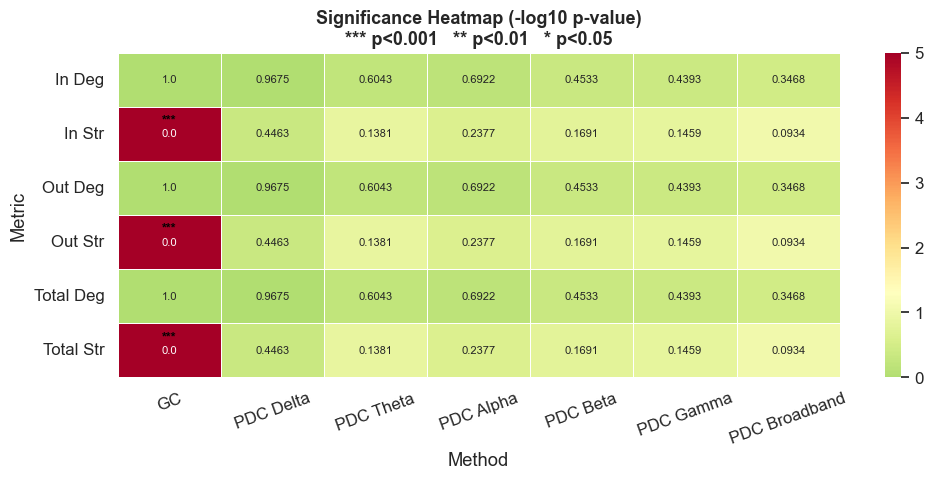

In [19]:
# ============================================================
# SEL INI: SIGNIFICANCE SUMMARY HEATMAP (VISUALISASI)
# ------------------------------------------------------------
# Sel ini membuat satu gambar ringkasan yang menampilkan
# nilai p dari uji utama dalam format heatmap warna:
#   - Baris (Y-axis) : 6 metrik graf
#   - Kolom (X-axis) : 7 metode (GC + 6 band PDC)
#   - Warna          : -log10(p) -> semakin merah = makin signifikan
#   - Anotasi        : nilai p asli ditampilkan di dalam kotak
#   - Tanda bintang  : * p<0.05, ** p<0.01, *** p<0.001
# Gambar disimpan ke: figures/significance_heatmap.png
# ============================================================

# ==============================================================================
# SECTION 8: SIGNIFICANCE SUMMARY HEATMAP
# ==============================================================================
summary_rows = []
for name, tests in all_main_tests.items():
    for _, row in tests.iterrows():
        summary_rows.append({
            'method': name, 'metric': row['metric'],
            'p_value': row['p_value'], 'significant': row['significant'],
        })
summary_df = pd.DataFrame(summary_rows)

# FIX: gunakan pivot_table (bukan pivot) untuk menghindari error duplikasi
pivot = summary_df.pivot_table(index='metric', columns='method', values='p_value', aggfunc='mean')
# Pastikan urutan kolom sesuai urutan DATASETS
method_order = [m for m in DATASETS.keys() if m in pivot.columns]
pivot = pivot[method_order]
metric_order = [SHORT[c] for c in MEAN_COLS if SHORT[c] in pivot.index]
pivot = pivot.loc[metric_order]

log_pivot = -np.log10(pivot.clip(lower=1e-10))

fig, ax = plt.subplots(figsize=(max(10, len(method_order)*1.5), 5))
sns.heatmap(log_pivot,
            annot=pivot.round(4).astype(str), fmt='',
            cmap='RdYlGn_r', linewidths=0.8, ax=ax,
            vmin=0, vmax=5, center=-np.log10(0.05),
            annot_kws={'size': 19}, cbar_kws={'shrink': 0.9})
ax.collections[0].colorbar.ax.tick_params(labelsize=17)

# Tambahkan tanda bintang signifikansi
for i, metric in enumerate(pivot.index):
    for j, method in enumerate(pivot.columns):
        p = pivot.loc[metric, method]
        stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        if stars:
            ax.text(j + 0.5, i + 0.25, stars,
                    ha='center', va='center', fontsize=17, fontweight='bold', color='black')

ax.set_title('Significance Heatmap (-log10 p-value)\n*** p<0.001   ** p<0.01   * p<0.05',
             fontsize=25, fontweight='bold')
ax.set_xlabel('Method', fontsize=21)
ax.set_ylabel('Metric', fontsize=21)
ax.tick_params(axis='y', rotation=0, labelsize=19)
ax.tick_params(axis='x', rotation=20, labelsize=19)
plt.tight_layout()

path = FIG_DIR / 'significance_heatmap.png'
fig.savefig(path, dpi=150, bbox_inches='tight', facecolor='white')
print(f'Saved: {path}')
plt.show()


---
## 9. Ringkasan Akhir

In [20]:
# ============================================================
# SEL INI: RINGKASAN AKHIR PHASE 2.3
# ------------------------------------------------------------
# Sel ini menampilkan daftar semua file CSV dan gambar yang
# telah dihasilkan selama eksekusi Phase 2.3, beserta
# ringkasan hasil uji hipotesis per metode:
#   [*] = metrik signifikan (p < 0.05)
#   [ ] = metrik tidak signifikan
# Gunakan ringkasan ini sebagai bahan untuk penulisan Bab 4
# (Hasil & Pembahasan) pada skripsi.
# ============================================================

# ==============================================================================
# SECTION 9: RINGKASAN AKHIR
# ==============================================================================
print('='*60)
print('PHASE 2.3 COMPLETE — Inferential Statistics')
print('='*60)

print(f'\nOutput CSV: {OUTPUT_DIR}')
for f in sorted(OUTPUT_DIR.glob('*.csv')):
    print(f'  {f.name}')

print(f'\nFigures: {FIG_DIR}')
for f in sorted(FIG_DIR.glob('*.png')):
    print(f'  {f.name}')

print(f'\n{"="*60}')
print('RINGKASAN: Metrik Signifikan per Metode')
print(f'{"="*60}')
for name, tests in all_main_tests.items():
    n_sig = tests['significant'].sum()
    sig_metrics = tests[tests['significant']]['metric'].tolist()
    print(f'\n  {name}: {n_sig}/{len(tests)} metrik signifikan')
    for _, row in tests.iterrows():
        mark = '[*]' if row['significant'] else '[ ]'
        print(f'    {mark} {row["metric"]:<12} {row["test"]:<18} p={row["p_value"]:.6f} {row["p_stars"]}')


PHASE 2.3 COMPLETE — Inferential Statistics

Output CSV: D:\Skripsi\new_data\phase_2_statistics\2.3_inferential_statistics\output
  effect_size_gc.csv
  effect_size_pdc_alpha.csv
  effect_size_pdc_beta.csv
  effect_size_pdc_broadband.csv
  effect_size_pdc_delta.csv
  effect_size_pdc_gamma.csv
  effect_size_pdc_theta.csv
  levene_gc.csv
  levene_pdc_alpha.csv
  levene_pdc_beta.csv
  levene_pdc_broadband.csv
  levene_pdc_delta.csv
  levene_pdc_gamma.csv
  levene_pdc_theta.csv
  lmm_gc.csv
  lmm_pdc_alpha.csv
  lmm_pdc_beta.csv
  lmm_pdc_broadband.csv
  lmm_pdc_delta.csv
  lmm_pdc_gamma.csv
  lmm_pdc_theta.csv
  main_tests_gc.csv
  main_tests_pdc_alpha.csv
  main_tests_pdc_beta.csv
  main_tests_pdc_broadband.csv
  main_tests_pdc_delta.csv
  main_tests_pdc_gamma.csv
  main_tests_pdc_theta.csv
  posthoc_gc.csv
  posthoc_pdc_delta.csv
  posthoc_pdc_theta.csv
  shapiro_gc.csv
  shapiro_pdc_alpha.csv
  shapiro_pdc_beta.csv
  shapiro_pdc_broadband.csv
  shapiro_pdc_delta.csv
  shapiro_pdc_gamma